# Stock Direction v7: Rolling Fixed-Window Validation

Main assumptions in this notebook:
- target is binary next-day direction (`UP` / `DOWN`),
- `no trade` comes from probability threshold, not from a third class,
- raw `stock_price` is excluded from model features,
- alternative data is shifted by 1 trading day for safer timing,
- model selection uses rolling fixed windows: 12 months train / 3 months validation,
- final evaluation uses an untouched 6-month holdout.


In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import classification_report

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 4)

RANDOM_STATE = 42
FINAL_HOLDOUT_MONTHS = 6
TRAIN_WINDOW_MONTHS = 12
ROLL_TEST_MONTHS = 3
ROLL_STEP_MONTHS = 1

LAG_STEPS = [1, 2, 3, 5]
TOP_K_CANDIDATES = [12, 20, 30, 40]
C_VALUES = [0.25, 0.5, 1.0, 2.0, 4.0]
P_THRESHOLDS = [0.52, 0.55, 0.58, 0.60]

ROLL_WINDOW = 20
MIN_ACTIVE_PCT = 0.05
ONE_WAY_COST_BPS = 5
ONE_WAY_COST = ONE_WAY_COST_BPS / 10000.0


In [4]:
def add_lags(frame, feature_cols, lags):
    parts = [frame]
    for lag in lags:
        shifted = frame[feature_cols].shift(lag)
        shifted = shifted.rename(columns={c: f"{c}_lag{lag}" for c in feature_cols})
        parts.append(shifted)
    return pd.concat(parts, axis=1)


def safe_pct_change(series, periods=1):
    out = series.pct_change(periods)
    return out.replace([np.inf, -np.inf], np.nan)


def signed_log1p(series):
    return np.sign(series) * np.log1p(np.abs(series))


def rolling_zscore(series, window=20, min_periods=10):
    mean = series.rolling(window, min_periods=min_periods).mean()
    std = series.rolling(window, min_periods=min_periods).std()
    return (series - mean) / std.replace(0, np.nan)


def select_top_k_mi(X_train, y_train, k):
    imp = SimpleImputer(strategy="median")
    X_i = imp.fit_transform(X_train)
    mi = mutual_info_classif(X_i, y_train, random_state=RANDOM_STATE)
    idx = np.argsort(mi)[::-1][: min(k, len(mi))]
    return [X_train.columns[i] for i in idx]


def fit_direction_model(train_X, train_y, selected_cols, c_value):
    model = Pipeline(
        steps=[
            ("imp", SimpleImputer(strategy="median")),
            ("sc", StandardScaler()),
            (
                "clf",
                LogisticRegression(
                    C=float(c_value),
                    class_weight="balanced",
                    max_iter=3000,
                    solver="liblinear",
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    )
    model.fit(train_X[selected_cols], train_y)
    return model


def signal_from_proba(p_up, p_threshold=0.55):
    return np.where(p_up >= p_threshold, 1, np.where(p_up <= 1 - p_threshold, -1, 0)).astype(int)


def backtest_from_signals(future_returns, signals, one_way_cost):
    r = np.asarray(future_returns, dtype=float)
    s = np.asarray(signals, dtype=int)
    trade_mask = s != 0
    strat_ret = np.zeros(len(s), dtype=float)
    strat_ret[trade_mask] = s[trade_mask] * r[trade_mask] - 2.0 * one_way_cost
    true_dir = np.where(r > 0, 1.0, 0.0)
    return strat_ret, trade_mask, s, true_dir, int(trade_mask.sum())


def perf_stats(strat_ret, trade_mask, executed_signal, trades):
    strat_ret = np.asarray(strat_ret, dtype=float)
    trade_mask = np.asarray(trade_mask, dtype=bool)
    executed_signal = np.asarray(executed_signal, dtype=int)

    equity = np.cumprod(1 + strat_ret)
    running_max = np.maximum.accumulate(equity)
    drawdown = equity / running_max - 1

    n_active = int(trade_mask.sum())
    hit_rate = np.nan
    if n_active > 0:
        hit_rate = float(np.mean(strat_ret[trade_mask] > 0))

    sharpe = 0.0
    if len(strat_ret) > 1 and np.std(strat_ret, ddof=1) > 0:
        sharpe = float(np.sqrt(252) * np.mean(strat_ret) / np.std(strat_ret, ddof=1))

    return {
        "cum_return": float(equity[-1] - 1),
        "sharpe": sharpe,
        "max_drawdown": float(drawdown.min()),
        "avg_daily_return": float(np.mean(strat_ret)),
        "active_days": n_active,
        "active_pct": float(np.mean(trade_mask)),
        "entries_exits": float(int(trades) * 2),
        "hit_rate_active": hit_rate,
    }


def build_fixed_windows(df, train_months, test_months, step_months):
    windows = []
    min_date = df["date"].min().normalize()
    max_date = df["date"].max().normalize()
    test_start = (min_date + pd.DateOffset(months=train_months)).normalize()
    window_id = 1

    while test_start <= max_date:
        train_start = (test_start - pd.DateOffset(months=train_months)).normalize()
        test_end = (test_start + pd.DateOffset(months=test_months)).normalize()

        tr = df[(df["date"] >= train_start) & (df["date"] < test_start)].copy()
        te = df[(df["date"] >= test_start) & (df["date"] < test_end)].copy()
        if te.empty:
            break
        if not tr.empty:
            windows.append(
                {
                    "window_id": window_id,
                    "train_start": train_start,
                    "train_end": test_start - pd.Timedelta(days=1),
                    "test_start": test_start,
                    "test_end": min(test_end - pd.Timedelta(days=1), te["date"].max()),
                    "train_df": tr,
                    "test_df": te,
                }
            )
            window_id += 1

        test_start = (test_start + pd.DateOffset(months=step_months)).normalize()

    return windows


data_root = next((p for p in [Path("../data/equity_data"), Path("data/equity_data")] if p.exists()), None)
if data_root is None:
    raise FileNotFoundError("Could not find data/equity_data")
model_dir = data_root / "model_data"
model_dir.mkdir(parents=True, exist_ok=True)

base_candidates = [
    model_dir / "stock_direction_dataset_v2_base_best.csv",
    model_dir / "stock_direction_dataset_base.csv",
]
base_path = next((p for p in base_candidates if p.exists()), None)
if base_path is None:
    raise FileNotFoundError("Run an earlier notebook that builds the base dataset first")

base_df = pd.read_csv(base_path)
base_df["date"] = pd.to_datetime(base_df["date"], errors="coerce")
base_df = base_df.dropna(subset=["date"]).sort_values("date").reset_index(drop=True)
for c in base_df.columns:
    if c != "date":
        base_df[c] = pd.to_numeric(base_df[c], errors="coerce")

if "stock_price" not in base_df.columns:
    raise ValueError("Base dataset must include stock_price")

features = pd.DataFrame({"date": base_df["date"]})
features["future_return_1d"] = base_df["stock_price"].shift(-1) / base_df["stock_price"] - 1
features["y_dir"] = np.where(features["future_return_1d"].isna(), np.nan, (features["future_return_1d"] > 0).astype(float))

features["ret_1d"] = base_df["stock_return_1d"] if "stock_return_1d" in base_df.columns else safe_pct_change(base_df["stock_price"], 1)
features["ret_2d"] = base_df["stock_return_2d"] if "stock_return_2d" in base_df.columns else safe_pct_change(base_df["stock_price"], 2)
features["ret_5d"] = base_df["stock_return_5d"] if "stock_return_5d" in base_df.columns else safe_pct_change(base_df["stock_price"], 5)
features["ret_10d"] = base_df["stock_return_10d"] if "stock_return_10d" in base_df.columns else safe_pct_change(base_df["stock_price"], 10)
features["volume_change_1d"] = base_df["stock_volume_change_1d"] if "stock_volume_change_1d" in base_df.columns else safe_pct_change(base_df["stock_volume"], 1)
features["volume_change_5d"] = base_df["stock_volume_change_5d"] if "stock_volume_change_5d" in base_df.columns else safe_pct_change(base_df["stock_volume"], 5)
features["realized_vol_5d"] = base_df["realized_vol_5d"] if "realized_vol_5d" in base_df.columns else features["ret_1d"].rolling(5).std()
features["realized_vol_10d"] = base_df["realized_vol_10d"] if "realized_vol_10d" in base_df.columns else features["ret_1d"].rolling(10).std()
features["price_vs_sma_5d"] = base_df["price_vs_sma_5d"] if "price_vs_sma_5d" in base_df.columns else base_df["stock_price"] / base_df["stock_price"].rolling(5).mean() - 1
features["price_vs_sma_10d"] = base_df["price_vs_sma_10d"] if "price_vs_sma_10d" in base_df.columns else base_df["stock_price"] / base_df["stock_price"].rolling(10).mean() - 1

log_volume = np.log1p(base_df["stock_volume"].clip(lower=0)) if "stock_volume" in base_df.columns else pd.Series(np.nan, index=base_df.index)
volume_sma20 = base_df["stock_volume"].rolling(ROLL_WINDOW, min_periods=10).mean() if "stock_volume" in base_df.columns else pd.Series(np.nan, index=base_df.index)
features["volume_z20"] = rolling_zscore(log_volume, ROLL_WINDOW)
features["volume_vs_sma_20d"] = base_df["stock_volume"] / volume_sma20 - 1 if "stock_volume" in base_df.columns else pd.Series(np.nan, index=base_df.index)

weekday = base_df["weekday"] if "weekday" in base_df.columns else base_df["date"].dt.dayofweek.astype(float)
features["weekday_sin"] = np.sin(2 * np.pi * weekday / 5.0)
features["weekday_cos"] = np.cos(2 * np.pi * weekday / 5.0)


def shifted_series(name, fill=None):
    if name not in base_df.columns:
        return pd.Series(np.nan, index=base_df.index, dtype="float64")
    s = base_df[name].shift(1)
    if fill == "ffill":
        s = s.ffill()
    elif fill == "zero":
        s = s.fillna(0.0)
    return s


trends_level = shifted_series("google_trends_score", fill="ffill")
if trends_level.notna().any():
    features["trends_level_z20"] = rolling_zscore(trends_level, ROLL_WINDOW)
    features["trends_change_1d"] = safe_pct_change(trends_level, 1).clip(-1.0, 1.0)
    features["trends_change_7d"] = safe_pct_change(trends_level, 7).clip(-1.0, 1.0)

gdelt_articles = shifted_series("gdelt_articles", fill="ffill")
if gdelt_articles.notna().any():
    log_articles = np.log1p(gdelt_articles.clip(lower=0))
    features["gdelt_articles_log"] = log_articles
    features["gdelt_articles_z20"] = rolling_zscore(log_articles, ROLL_WINDOW)
    features["gdelt_articles_change_1d"] = safe_pct_change(gdelt_articles, 1).clip(-3.0, 3.0)

gdelt_sentiment = shifted_series("gdelt_sentiment_score", fill="ffill")
if gdelt_sentiment.notna().any():
    features["gdelt_sentiment_score"] = gdelt_sentiment
    features["gdelt_sentiment_5d"] = gdelt_sentiment.rolling(5, min_periods=3).mean()


def add_reddit_block(prefix):
    posts_col = f"{prefix}reddit_posts"
    score_col = f"{prefix}reddit_score_sum"
    comments_col = f"{prefix}reddit_comments_sum"
    vader_col = f"{prefix}reddit_vader_weighted_mean" if f"{prefix}reddit_vader_weighted_mean" in base_df.columns else f"{prefix}reddit_vader_mean"
    finbert_col = f"{prefix}reddit_finbert_weighted_mean" if f"{prefix}reddit_finbert_weighted_mean" in base_df.columns else f"{prefix}reddit_finbert_mean"
    gap_col = f"{prefix}sent_gap_mean"

    posts = shifted_series(posts_col, fill="zero")
    if posts_col in base_df.columns:
        log_posts = np.log1p(posts.clip(lower=0))
        features[f"{prefix}log_posts"] = log_posts
        features[f"{prefix}posts_z20"] = rolling_zscore(log_posts, ROLL_WINDOW)
        features[f"{prefix}active_flag"] = (posts > 0).astype(float)

    if score_col in base_df.columns:
        score = shifted_series(score_col, fill="zero")
        features[f"{prefix}score_signed_log"] = signed_log1p(score)

    if comments_col in base_df.columns:
        comments = shifted_series(comments_col, fill="zero")
        if comments.nunique(dropna=True) > 1:
            features[f"{prefix}log_comments_sum"] = np.log1p(comments.clip(lower=0))

    if vader_col in base_df.columns:
        features[f"{prefix}vader_mean"] = shifted_series(vader_col, fill="zero")

    if finbert_col in base_df.columns:
        features[f"{prefix}finbert_mean"] = shifted_series(finbert_col, fill="zero")

    if gap_col in base_df.columns:
        features[f"{prefix}sent_gap_mean"] = shifted_series(gap_col, fill="zero")


add_reddit_block("subm_")
add_reddit_block("comm_")

candidate_cols = [c for c in features.columns if c not in ["date", "future_return_1d", "y_dir"]]
constant_cols = [c for c in candidate_cols if features[c].nunique(dropna=True) <= 1]
if constant_cols:
    features = features.drop(columns=constant_cols)

base_features = [c for c in features.columns if c not in ["date", "future_return_1d", "y_dir"]]

base_out_path = model_dir / "stock_direction_dataset_v7_base.csv"
features.to_csv(base_out_path, index=False)

core = features[["date", "future_return_1d", "y_dir"] + base_features].copy()
lagged_df = add_lags(core, base_features, LAG_STEPS)
lagged_df = lagged_df.dropna(subset=["future_return_1d", "y_dir"]).reset_index(drop=True)
model_features = [c for c in lagged_df.columns if c not in ["date", "future_return_1d", "y_dir"]]

lagged_out_path = model_dir / "stock_direction_dataset_v7_lagged.csv"
lagged_df.to_csv(lagged_out_path, index=False)

final_holdout_start = (lagged_df["date"].max() - pd.DateOffset(months=FINAL_HOLDOUT_MONTHS)).normalize()
pre_holdout_df = lagged_df[lagged_df["date"] < final_holdout_start].copy()
final_test_df = lagged_df[lagged_df["date"] >= final_holdout_start].copy()
final_train_start = (final_holdout_start - pd.DateOffset(months=TRAIN_WINDOW_MONTHS)).normalize()
final_train_df = lagged_df[(lagged_df["date"] >= final_train_start) & (lagged_df["date"] < final_holdout_start)].copy()

if pre_holdout_df.empty or final_test_df.empty or final_train_df.empty:
    raise ValueError("One of the fixed-window splits is empty. Check date coverage.")

rolling_windows = build_fixed_windows(pre_holdout_df, TRAIN_WINDOW_MONTHS, ROLL_TEST_MONTHS, ROLL_STEP_MONTHS)
if not rolling_windows:
    raise RuntimeError("No rolling windows generated for model selection")

print(f"Base source: {base_path}")
print(f"Rows total: {len(lagged_df):,}")
print(f"Engineered base features: {len(base_features)}")
print(f"Model features with lags: {len(model_features)}")
print(f"Removed constant columns: {constant_cols}")
print(f"Rolling windows: {len(rolling_windows)}")
print(f"Final train window: {final_train_df['date'].min().date()} -> {final_train_df['date'].max().date()} ({len(final_train_df):,} rows)")
print(f"Final holdout: {final_test_df['date'].min().date()} -> {final_test_df['date'].max().date()} ({len(final_test_df):,} rows)")
print(base_out_path)
print(lagged_out_path)
display(features.head())


Base source: ..\data\equity_data\model_data\stock_direction_dataset_v2_base_best.csv
Rows total: 750
Engineered base features: 37
Model features with lags: 185
Removed constant columns: []
Rolling windows: 18
Final train window: 2024-07-01 -> 2025-06-27 (249 rows)
Final holdout: 2025-06-30 -> 2025-12-29 (127 rows)
..\data\equity_data\model_data\stock_direction_dataset_v7_base.csv
..\data\equity_data\model_data\stock_direction_dataset_v7_lagged.csv


,date,future_return_1d,y_dir,ret_1d,ret_2d,ret_5d,ret_10d,volume_change_1d,volume_change_5d,realized_vol_5d,...,subm_vader_mean,subm_finbert_mean,subm_sent_gap_mean,comm_log_posts,comm_posts_z20,comm_active_flag,comm_score_signed_log,comm_vader_mean,comm_finbert_mean,comm_sent_gap_mean
0,2023-01-03,0.051249,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,0.000000,0.000000,0.000000,NaN,0.0,0.000000,0.000000,0.000000,0.000000
1,2023-01-04,-0.029039,0.0,0.051249,NaN,NaN,NaN,-0.220455,NaN,NaN,...,0.305369,-0.175264,0.422904,6.118097,NaN,1.0,7.609367,0.187674,-0.137697,0.315346
2,2023-01-05,0.024651,1.0,-0.029039,0.020722,NaN,NaN,-0.124191,NaN,NaN,...,0.596288,-0.384605,1.015222,5.117994,NaN,1.0,6.976348,0.133119,-0.107439,0.281207
3,2023-01-06,0.059349,1.0,0.024651,-0.005104,NaN,NaN,0.398293,NaN,NaN,...,0.258447,-0.780263,0.734666,4.262680,NaN,1.0,7.568896,0.126862,-0.062067,0.229124
4,2023-01-09,-0.007681,0.0,0.059349,0.085463,NaN,NaN,-0.138640,NaN,NaN,...,-0.486909,-0.822936,0.742524,4.219508,NaN,1.0,6.317165,0.279178,-0.245605,0.473386


,top_k,c_value,p_threshold,rolling_score,rolling_mean_cum_return,rolling_median_cum_return,rolling_mean_sharpe,rolling_mean_active_pct,rolling_mean_hit_rate,rolling_profitable_window_pct,n_windows,final_holdout_start
0,12,0.25,0.60,0.232678,0.066740,0.011170,0.620109,0.447522,0.508681,0.555556,18,2025-06-29
1,12,2.00,0.60,0.202986,0.056964,0.023142,0.560707,0.479236,0.504763,0.500000,18,2025-06-29
2,12,0.50,0.60,0.200907,0.062572,-0.003572,0.577169,0.466639,0.498953,0.500000,18,2025-06-29
3,12,1.00,0.60,0.185862,0.056786,-0.003572,0.535646,0.475694,0.496394,0.500000,18,2025-06-29
4,20,0.50,0.60,0.178515,0.042897,0.050953,0.340785,0.580433,0.510288,0.722222,18,2025-06-29
5,20,1.00,0.60,0.177165,0.049753,0.051504,0.336362,0.586757,0.510589,0.722222,18,2025-06-29
6,12,4.00,0.60,0.150907,0.036779,0.023142,0.415389,0.490820,0.498676,0.500000,18,2025-06-29
7,30,1.00,0.55,0.148788,0.013550,0.109208,0.304733,0.832643,0.518592,0.555556,18,2025-06-29
8,30,0.50,0.55,0.133713,0.013915,0.110714,0.263103,0.831577,0.514187,0.555556,18,2025-06-29
9,30,4.00,0.58,0.129964,0.023557,0.105203,0.256062,0.736936,0.514654,0.555556,18,2025-06-29


Best config: {'top_k': 12, 'c_value': 0.25, 'p_threshold': 0.6, 'rolling_score': 0.2326780160820798, 'rolling_mean_cum_return': 0.06674045941720214, 'rolling_median_cum_return': 0.01116995762720685, 'rolling_mean_sharpe': 0.6201092119364954, 'rolling_mean_active_pct': 0.4475219977898295, 'rolling_mean_hit_rate': 0.5086809569319679, 'rolling_profitable_window_pct': 0.5555555555555556, 'n_windows': 18, 'final_holdout_start': '2025-06-29'}


,mean_cum_return,median_cum_return,mean_sharpe,mean_active_pct,mean_hit_rate,profitable_window_pct,n_windows
0,0.0667,0.0112,0.6201,0.4475,0.5087,0.5556,18


,window_id,train_start,train_end,test_start,test_end,cum_return,sharpe,max_drawdown,avg_daily_return,active_days,active_pct,entries_exits,hit_rate_active
0,1,2023-01-03,2024-01-02,2024-01-03,2024-04-02,-0.1205,-1.1030,-0.2852,-0.0017,37,0.5968,74.0,0.4595
1,2,2023-02-03,2024-02-02,2024-02-03,2024-05-02,0.2046,1.6769,-0.1093,0.0035,41,0.6613,82.0,0.4878
2,3,2023-03-03,2024-03-02,2024-03-03,2024-05-31,-0.2190,-1.6459,-0.2447,-0.0034,40,0.6349,80.0,0.4500
3,4,2023-04-03,2024-04-02,2024-04-03,2024-07-02,0.0013,0.2268,-0.3017,0.0004,37,0.5873,74.0,0.4865
4,5,2023-05-03,2024-05-02,2024-05-03,2024-08-02,0.4056,3.0095,-0.1196,0.0059,37,0.5873,74.0,0.6486
5,6,2023-06-03,2024-06-02,2024-06-03,2024-08-30,0.4488,3.5051,-0.0816,0.0063,30,0.4762,60.0,0.6667
6,7,2023-07-03,2024-07-02,2024-07-03,2024-10-02,0.7970,6.0358,-0.0474,0.0095,30,0.4688,60.0,0.8000
7,8,2023-08-03,2024-08-02,2024-08-03,2024-11-01,-0.1475,-1.3383,-0.1734,-0.0022,43,0.6719,86.0,0.4884
8,9,2023-09-03,2024-09-02,2024-09-03,2024-12-02,0.2601,1.8083,-0.1268,0.0043,30,0.4688,60.0,0.5333
9,10,2023-10-03,2024-10-02,2024-10-03,2025-01-02,0.2632,1.6159,-0.2049,0.0048,41,0.6508,82.0,0.5366


,model,split,cum_return,sharpe,max_drawdown,avg_daily_return,active_days,active_pct,entries_exits,hit_rate_active
0,BuyHold,train,0.1801,0.5903,-0.5714,0.0017,249,1.0000,498.0,0.4980
1,BuyHold,test,0.2602,1.2106,-0.1799,0.0023,127,1.0000,254.0,0.5433
2,Directional_v7,train,1.5532,2.8144,-0.1478,0.0040,85,0.3414,170.0,0.6353
3,Directional_v7,test,-0.0219,-0.0585,-0.2427,-0.0001,42,0.3307,84.0,0.5000


Best setup -> top_k=12, C=0.25, p_threshold=0.6
Rolling windows used for selection: 18
Final holdout start: 2025-06-29
Costs: 5 bps one-way
Directional report on active holdout trades (long=1, short=0):
              precision    recall  f1-score   support

           0       0.52      0.73      0.60        22
           1       0.45      0.25      0.32        20

    accuracy                           0.50        42
   macro avg       0.49      0.49      0.46        42
weighted avg       0.49      0.50      0.47        42



,feature,coef,abs_coef
0,volume_z20_lag5,-0.320180,0.320180
1,comm_finbert_mean_lag5,0.223657,0.223657
2,realized_vol_10d_lag2,0.196232,0.196232
3,volume_vs_sma_20d_lag1,0.179691,0.179691
4,comm_finbert_mean,0.129303,0.129303
5,trends_change_7d,0.061843,0.061843
6,gdelt_sentiment_score,-0.057990,0.057990
7,gdelt_sentiment_5d_lag2,-0.052930,0.052930
8,ret_2d_lag1,-0.044172,0.044172
9,comm_log_posts_lag5,0.041196,0.041196


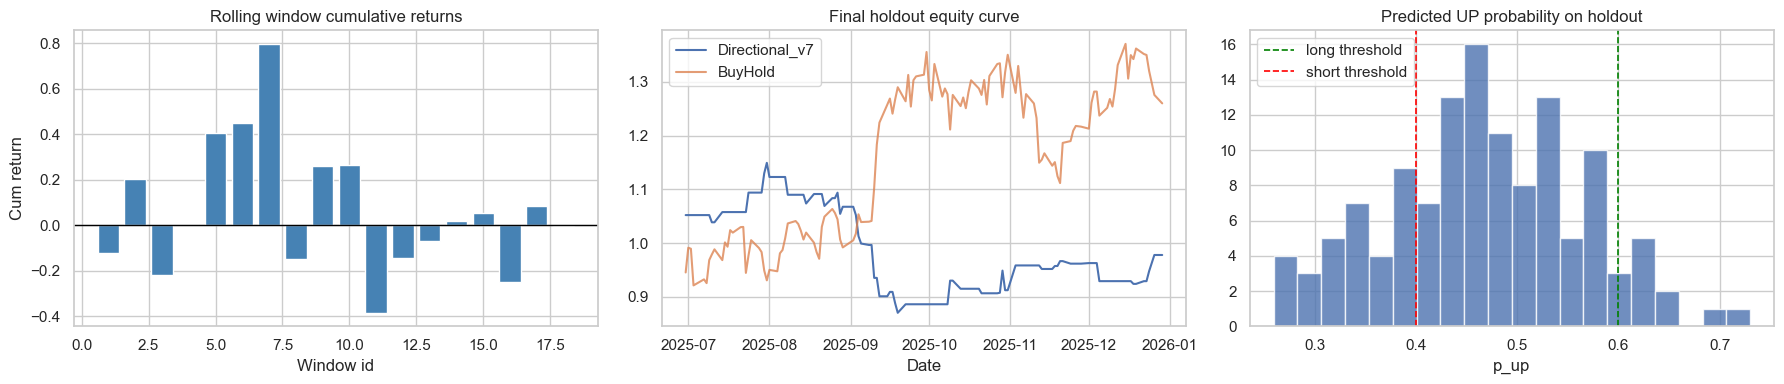

..\data\equity_data\model_data\stock_direction_v7_search_results.csv
..\data\equity_data\model_data\stock_direction_v7_rolling_window_results.csv
..\data\equity_data\model_data\stock_direction_v7_metrics.csv
..\data\equity_data\model_data\stock_direction_v7_test_predictions.csv
..\data\equity_data\model_data\stock_direction_v7_selected_features.csv


In [5]:
search_rows = []

for top_k in TOP_K_CANDIDATES:
    for c_val in C_VALUES:
        for p_thr in P_THRESHOLDS:
            window_stats = []
            for window in rolling_windows:
                tr = window["train_df"]
                te = window["test_df"]
                y_tr = tr["y_dir"].to_numpy(dtype=int)

                cols = select_top_k_mi(tr[model_features], y_tr, top_k)
                model = fit_direction_model(tr, y_tr, cols, c_val)

                p_up = model.predict_proba(te[cols])[:, 1]
                sig = signal_from_proba(p_up, p_threshold=p_thr)
                strat_ret, trade_mask, sig_exec, true_dir, n_trades = backtest_from_signals(
                    te["future_return_1d"].to_numpy(),
                    sig,
                    ONE_WAY_COST,
                )
                stats = perf_stats(strat_ret, trade_mask, sig_exec, n_trades)
                window_stats.append(stats)

            mean_cum = float(np.mean([s["cum_return"] for s in window_stats]))
            median_cum = float(np.median([s["cum_return"] for s in window_stats]))
            mean_sharpe = float(np.mean([s["sharpe"] for s in window_stats]))
            mean_active = float(np.mean([s["active_pct"] for s in window_stats]))
            hit_values = [s["hit_rate_active"] for s in window_stats if not np.isnan(s["hit_rate_active"])]
            mean_hit = float(np.mean(hit_values)) if hit_values else 0.5
            profitable_pct = float(np.mean([s["cum_return"] > 0 for s in window_stats]))

            score = 0.35 * mean_sharpe + 0.25 * median_cum + 0.20 * (profitable_pct - 0.5) + 0.20 * (mean_hit - 0.5)
            if mean_active < MIN_ACTIVE_PCT:
                score -= 0.25

            search_rows.append(
                {
                    "top_k": top_k,
                    "c_value": c_val,
                    "p_threshold": p_thr,
                    "rolling_score": score,
                    "rolling_mean_cum_return": mean_cum,
                    "rolling_median_cum_return": median_cum,
                    "rolling_mean_sharpe": mean_sharpe,
                    "rolling_mean_active_pct": mean_active,
                    "rolling_mean_hit_rate": mean_hit,
                    "rolling_profitable_window_pct": profitable_pct,
                    "n_windows": len(window_stats),
                    "final_holdout_start": str(final_holdout_start.date()),
                }
            )

search_df = pd.DataFrame(search_rows).sort_values("rolling_score", ascending=False).reset_index(drop=True)
if search_df.empty:
    raise RuntimeError("No search results generated")

display(search_df.head(10))
best_cfg = search_df.iloc[0].to_dict()
print("Best config:", best_cfg)

top_k = int(best_cfg["top_k"])
c_val = float(best_cfg["c_value"])
p_thr = float(best_cfg["p_threshold"])

rolling_best_rows = []
for window in rolling_windows:
    tr = window["train_df"]
    te = window["test_df"]
    y_tr = tr["y_dir"].to_numpy(dtype=int)

    cols = select_top_k_mi(tr[model_features], y_tr, top_k)
    model = fit_direction_model(tr, y_tr, cols, c_val)
    p_up = model.predict_proba(te[cols])[:, 1]
    sig = signal_from_proba(p_up, p_threshold=p_thr)
    strat_ret, trade_mask, sig_exec, true_dir, n_trades = backtest_from_signals(
        te["future_return_1d"].to_numpy(),
        sig,
        ONE_WAY_COST,
    )
    stats = perf_stats(strat_ret, trade_mask, sig_exec, n_trades)
    rolling_best_rows.append(
        {
            "window_id": window["window_id"],
            "train_start": str(window["train_start"].date()),
            "train_end": str(window["train_end"].date()),
            "test_start": str(window["test_start"].date()),
            "test_end": str(window["test_end"].date()),
            **stats,
        }
    )

rolling_best_df = pd.DataFrame(rolling_best_rows)
rolling_summary_df = pd.DataFrame(
    [
        {
            "mean_cum_return": rolling_best_df["cum_return"].mean(),
            "median_cum_return": rolling_best_df["cum_return"].median(),
            "mean_sharpe": rolling_best_df["sharpe"].mean(),
            "mean_active_pct": rolling_best_df["active_pct"].mean(),
            "mean_hit_rate": rolling_best_df["hit_rate_active"].dropna().mean(),
            "profitable_window_pct": (rolling_best_df["cum_return"] > 0).mean(),
            "n_windows": len(rolling_best_df),
        }
    ]
)
display(rolling_summary_df.round(4))
display(rolling_best_df.head(10).round(4))

y_train = final_train_df["y_dir"].to_numpy(dtype=int)
y_test = final_test_df["y_dir"].to_numpy(dtype=int)

sel_cols = select_top_k_mi(final_train_df[model_features], y_train, top_k)
final_model = fit_direction_model(final_train_df, y_train, sel_cols, c_val)

p_up_train = final_model.predict_proba(final_train_df[sel_cols])[:, 1]
p_up_test = final_model.predict_proba(final_test_df[sel_cols])[:, 1]

sig_train = signal_from_proba(p_up_train, p_threshold=p_thr)
sig_test = signal_from_proba(p_up_test, p_threshold=p_thr)

ret_train, mask_train, sig_exec_train, true_dir_train, n_trades_train = backtest_from_signals(
    final_train_df["future_return_1d"].to_numpy(),
    sig_train,
    ONE_WAY_COST,
)
ret_test, mask_test, sig_exec_test, true_dir_test, n_trades_test = backtest_from_signals(
    final_test_df["future_return_1d"].to_numpy(),
    sig_test,
    ONE_WAY_COST,
)

stats_train = perf_stats(ret_train, mask_train, sig_exec_train, n_trades_train)
stats_test = perf_stats(ret_test, mask_test, sig_exec_test, n_trades_test)

bh_sig_train = np.ones(len(final_train_df), dtype=int)
bh_sig_test = np.ones(len(final_test_df), dtype=int)
bh_train, bh_mask_train, bh_exec_train, bh_true_train, bh_ntr_train = backtest_from_signals(
    final_train_df["future_return_1d"].to_numpy(),
    bh_sig_train,
    ONE_WAY_COST,
)
bh_test, bh_mask_test, bh_exec_test, bh_true_test, bh_ntr_test = backtest_from_signals(
    final_test_df["future_return_1d"].to_numpy(),
    bh_sig_test,
    ONE_WAY_COST,
)
bh_stats_train = perf_stats(bh_train, bh_mask_train, bh_exec_train, bh_ntr_train)
bh_stats_test = perf_stats(bh_test, bh_mask_test, bh_exec_test, bh_ntr_test)

metrics_df = pd.DataFrame(
    [
        {"model": "BuyHold", "split": "train", **bh_stats_train},
        {"model": "BuyHold", "split": "test", **bh_stats_test},
        {"model": "Directional_v7", "split": "train", **stats_train},
        {"model": "Directional_v7", "split": "test", **stats_test},
    ]
)
display(metrics_df.round(4))

print(f"Best setup -> top_k={top_k}, C={c_val}, p_threshold={p_thr}")
print(f"Rolling windows used for selection: {len(rolling_best_df)}")
print(f"Final holdout start: {final_holdout_start.date()}")
print(f"Costs: {ONE_WAY_COST_BPS} bps one-way")

active_mask = mask_test
if active_mask.any():
    active_true = true_dir_test[active_mask].astype(int)
    active_pred = (sig_exec_test[active_mask] > 0).astype(int)
    print("Directional report on active holdout trades (long=1, short=0):")
    print(classification_report(active_true, active_pred, zero_division=0))
else:
    print("No active trades on final holdout.")

coef = final_model.named_steps["clf"].coef_.ravel()
features_df = pd.DataFrame(
    {
        "feature": sel_cols,
        "coef": coef,
        "abs_coef": np.abs(coef),
    }
).sort_values("abs_coef", ascending=False).reset_index(drop=True)
display(features_df.head(20))

eq_strat = np.cumprod(1 + ret_test)
eq_bh = np.cumprod(1 + bh_test)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].bar(rolling_best_df["window_id"], rolling_best_df["cum_return"], color="steelblue")
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("Rolling window cumulative returns")
axes[0].set_xlabel("Window id")
axes[0].set_ylabel("Cum return")

axes[1].plot(final_test_df["date"], eq_strat, label="Directional_v7")
axes[1].plot(final_test_df["date"], eq_bh, label="BuyHold", alpha=0.8)
axes[1].set_title("Final holdout equity curve")
axes[1].set_xlabel("Date")
axes[1].legend()

axes[2].hist(p_up_test, bins=20, alpha=0.8)
axes[2].axvline(p_thr, color="green", linestyle="--", linewidth=1.2, label="long threshold")
axes[2].axvline(1 - p_thr, color="red", linestyle="--", linewidth=1.2, label="short threshold")
axes[2].set_title("Predicted UP probability on holdout")
axes[2].set_xlabel("p_up")
axes[2].legend()

plt.tight_layout()
plt.show()

preds_df = pd.DataFrame(
    {
        "date": final_test_df["date"].values,
        "future_return_1d": final_test_df["future_return_1d"].values,
        "y_true": y_test,
        "p_up": p_up_test,
        "signal_raw": sig_test,
        "signal_executed": sig_exec_test,
        "trade_executed": mask_test,
        "strategy_return": ret_test,
        "trade_true_dir": true_dir_test,
    }
)

search_path = model_dir / "stock_direction_v7_search_results.csv"
rolling_path = model_dir / "stock_direction_v7_rolling_window_results.csv"
metrics_path = model_dir / "stock_direction_v7_metrics.csv"
preds_path = model_dir / "stock_direction_v7_test_predictions.csv"
features_path = model_dir / "stock_direction_v7_selected_features.csv"

search_df.to_csv(search_path, index=False)
rolling_best_df.to_csv(rolling_path, index=False)
metrics_df.to_csv(metrics_path, index=False)
preds_df.to_csv(preds_path, index=False)
features_df.to_csv(features_path, index=False)

print(search_path)
print(rolling_path)
print(metrics_path)
print(preds_path)
print(features_path)
